# 04 · Benchmark evidence and submission audit

**Read the saved outputs; running this notebook is optional.** This is an executable review of the earlier benchmark and submission records, not a new model-training run.

The 2022–2025 outcomes have already been consumed. The current 124-feature experiment in notebook 03 does **not** retroactively replace the earlier model recipe. Historical neural and margin-model results are not current-schema reruns. Original implementation history remains in Git.

The official competition metric is **Brier score**, the mean squared error of predicted win probabilities. Historical local benchmark coverage and the official scored game set are different; do not compare their scalar scores as though they used identical games.

In [1]:
from pathlib import Path, PureWindowsPath
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from march_mania.notebook_support import table, style
from march_mania.publication.submission import verify_text_evidence

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
HISTORY = ROOT / "reports/final_2026"
style()
MANIFEST = pd.read_csv(HISTORY / "artifact_manifest.csv")
MANIFEST["filename"] = MANIFEST.Path.map(lambda value: PureWindowsPath(value).name)
verified = []
for filename in ["locked_benchmark_metrics.csv", "development_handoff_decisions.csv",
                 "development_neural_model_audit.csv", "benchmark_consumption_lock.json"]:
    record = MANIFEST.loc[MANIFEST.filename.eq(filename)]
    assert len(record) == 1, filename
    form = verify_text_evidence(HISTORY / filename, record.iloc[0].SHA256)
    verified.append({"Evidence file": filename, "Integrity": form})
table(pd.DataFrame(verified))

Evidence file,Integrity
locked_benchmark_metrics.csv,recorded Windows bytes; Git-normalized line endings
development_handoff_decisions.csv,recorded Windows bytes; Git-normalized line endings
development_neural_model_audit.csv,recorded Windows bytes; Git-normalized line endings
benchmark_consumption_lock.json,recorded Windows bytes; Git-normalized line endings


## Historical benchmark · what was measured

The table below is the **recorded 2022–2025 prequential-refit benchmark**: the frozen historical procedure was refit with seasons available before each evaluation year. The alternative static-block protocol kept training through 2021.

The saved tables contain 67 tournament games per gender per season, including play-ins. The official 2026 Kaggle evaluation excludes play-ins. The metric formula is the same; the scored population is not. Original prediction bytes are required to independently recompute every game-level historical metric.

In [2]:
metrics = pd.read_csv(HISTORY / "locked_benchmark_metrics.csv")
seasons = pd.read_csv(HISTORY / "locked_benchmark_by_season.csv")
assert not seasons.duplicated(["Protocol", "StreamID", "Season"]).any()
assert set(seasons.Season) == {2022, 2023, 2024, 2025}
assert seasons.Rows.eq(67).all()
assert seasons.Brier.between(0, 1).all()
check = seasons.assign(total_loss=seasons.Rows * seasons.Brier).groupby(
    ["Protocol", "StreamID"]).agg(rows=("Rows", "sum"), loss=("total_loss", "sum"),
                                 mean_season=("Brier", "mean")).reset_index()
check = check.merge(metrics, on=["Protocol", "StreamID"], validate="one_to_one")
assert np.allclose(check.loss / check.rows, check.GameWeightedBrier, rtol=0, atol=1e-12)
assert np.allclose(check.mean_season, check.MacroSeasonBrier, rtol=0, atol=1e-12)
assert (check.rows == check.Rows).all()
benchmark = metrics.loc[metrics.Protocol.eq("prequential_refit")].copy()
table(benchmark[["Gender", "Role", "ModelDisplay", "Rows", "GameWeightedBrier",
                 "MacroSeasonBrier", "LogLoss", "ROCAUC", "AveragePrecision"]])
display(Markdown("**Verified:** season-level aggregation reproduces the recorded Brier tables. "
                 "This checks aggregate consistency, not the missing historical game-level predictions."))

Gender,Role,ModelDisplay,Rows,GameWeightedBrier,MacroSeasonBrier,LogLoss,ROCAUC,AveragePrecision
M,primary,Rich elastic-net logistic,268,0.193297,0.193297,0.570781,0.761677,0.792653
M,development_blend,Development-frozen blend,268,0.198565,0.198565,0.582779,0.750114,0.785043
M,challenger,Histogram boosting,268,0.201104,0.201104,0.590295,0.745557,0.781603
W,challenger,XGBoost classifier,268,0.142382,0.142382,0.435021,0.881902,0.854240
W,development_blend,Development-frozen blend,268,0.143590,0.143590,0.442049,0.883143,0.853936
W,primary,Seed logistic,268,0.152802,0.152802,0.467632,0.866336,0.834296


**Verified:** season-level aggregation reproduces the recorded Brier tables. This checks aggregate consistency, not the missing historical game-level predictions.

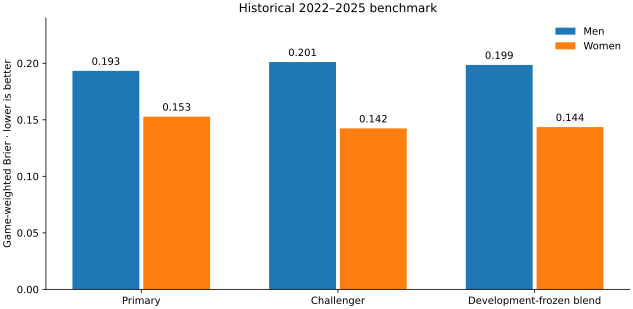

In [3]:
roles = ["primary", "challenger", "development_blend"]
fig, ax = plt.subplots(figsize=(8.8, 4.3), constrained_layout=True)
positions = np.arange(len(roles))
for offset, gender, label in [(-0.18, "M", "Men"), (0.18, "W", "Women")]:
    values = benchmark.loc[benchmark.Gender.eq(gender)].set_index("Role").loc[roles, "GameWeightedBrier"]
    bars = ax.bar(positions + offset, values, width=0.34, label=label)
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xticks(positions, ["Primary", "Challenger", "Development-frozen blend"])
ax.set(title="Historical 2022–2025 benchmark", ylabel="Game-weighted Brier · lower is better", ylim=(0, 0.24))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
from io import StringIO
from IPython.display import SVG
with plt.rc_context({"svg.fonttype": "none"}):
    svg = StringIO()
    fig.savefig(svg, format="svg")
display(SVG(svg.getvalue()))
plt.close(fig)

**Interpretation.** The historical men's primary leads its two alternatives on this local benchmark. The women's challenger leads the other historical women's streams. That does not authorize selecting a new combined recipe after examining these outcomes.

Probability quality matters more than a single classification threshold. Calibration slope, expected calibration error and log loss complement Brier; the detailed current-schema calibration plots are in notebook 03.

In [4]:
table(benchmark[["Gender", "Role", "CalibrationSlope", "ECE", "LogLoss",
                 "Precision", "Recall", "F1"]])
neural = pd.read_csv(HISTORY / "development_neural_model_audit.csv")
table(neural[["Gender", "Architecture", "ModelDisplay", "MacroSeasonBrier", "GameWeightedBrier"]])

Gender,Role,CalibrationSlope,ECE,LogLoss,Precision,Recall,F1
M,primary,0.867049,0.085822,0.570781,0.731250,0.759740,0.745223
M,development_blend,0.749573,0.071411,0.582779,0.707317,0.753247,0.729560
M,challenger,0.699720,0.077034,0.590295,0.709877,0.746753,0.727848
W,challenger,1.382159,0.045763,0.435021,0.769231,0.756303,0.762712
W,development_blend,1.581810,0.066535,0.442049,0.780702,0.747899,0.763948
W,primary,1.610333,0.092696,0.467632,0.754386,0.722689,0.738197


Gender,Architecture,ModelDisplay,MacroSeasonBrier,GameWeightedBrier
M,separate_gender,PyTorch MLP,0.191687,0.191573
M,pooled_common,TensorFlow MLP,0.192525,0.192445
M,separate_gender,TensorFlow MLP,0.193766,0.193633
M,pooled_common,PyTorch MLP,0.196165,0.196025
W,separate_gender,TensorFlow MLP,0.156218,0.156218
W,pooled_common,TensorFlow MLP,0.160189,0.160189
W,separate_gender,PyTorch MLP,0.161518,0.161518
W,pooled_common,PyTorch MLP,0.161834,0.161834


## Submission records · evidence is not a submission receipt

The earlier workflow recorded primary, challenger and development-blend CSVs, plus a default alias. A manifest can identify those files but cannot replace their bytes. The table checks any matching file actually present in this checkout; absent files remain explicitly unverified.

In [5]:
submissions = pd.read_csv(HISTORY / "submission_manifest.csv")
from march_mania.runtime import digest
rows = []
for record in submissions.itertuples():
    filename = PureWindowsPath(record.Path).name
    path = ROOT / "submissions" / filename
    status = "not present in this checkout; manifest only"
    if path.is_file():
        assert digest(path) == record.SHA256, f"Submission checksum mismatch: {filename}"
        status = "exact prediction-file checksum verified"
    rows.append({"Product": record.Submission, "File": filename,
                 "Recorded rows": record.Rows, "File verification": status})
assert submissions.Rows.eq(132133).all()
assert set(submissions.Submission) == {"primary", "challenger", "development_blend", "default"}
table(pd.DataFrame(rows))
scores = pd.read_csv(ROOT / "reports/submission_portfolio/kaggle_scores.csv")
original = scores.loc[scores.Candidate.isin(["primary", "challenger", "development_blend"])]
table(original[["Candidate", "KaggleBrier", "ObservedAtUTC"]].sort_values("KaggleBrier"))
display(Markdown("These scores are **repository-recorded**, not independently authenticated Kaggle receipts. "
                 "Later temperature refinements are post-result sensitivity analyses, not untouched validation."))

Product,File,Recorded rows,File verification
primary,submission_2026_primary.csv,132133,not present in this checkout; manifest only
challenger,submission_2026_challenger.csv,132133,not present in this checkout; manifest only
development_blend,submission_2026_development_blend.csv,132133,not present in this checkout; manifest only
default,submission_2026.csv,132133,not present in this checkout; manifest only


Candidate,KaggleBrier,ObservedAtUTC
challenger,0.129901,2026-08-31T00:00:00Z
development_blend,0.131817,2026-08-31T00:00:00Z
primary,0.142112,2026-08-31T00:00:00Z


These scores are **repository-recorded**, not independently authenticated Kaggle receipts. Later temperature refinements are post-result sensitivity analyses, not untouched validation.

## Releasing a real prediction file

Use `scripts/portfolio_release.py` with the actual CSV and the official `SampleSubmissionStage2.csv`. It verifies exact ID coverage and ordering, lower-TeamID orientation, finite probabilities in [0, 1], and the recorded checksum when supplied. A successful release preserves the original bytes, an audit and a resumable checkpoint. Optional private S3 replication is independent of the notebook kernel.

This command **does not generate new probabilities or submit to Kaggle**. It cannot restore missing historical model/prediction files from a score table. The original competitive deadline was **March 19, 2026, 16:00 UTC**; any later release must be described as retrospective, with late-submission availability checked on Kaggle.

**Review complete.** Current data, features and model evidence are in notebooks 00–03; the earlier benchmark and submission lineage are preserved here without implying that they share the new feature schema.

Sources: [official evaluation and timeline](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) · [organizer's Stage 2 scoring clarification](https://www.kaggle.com/competitions/march-machine-learning-mania-2026/discussion/680419) · local tables under `reports/final_2026/` and `reports/submission_portfolio/`.